# **05. Final Evaluation and Error Analysis**

This notebook reviews the final saved results, inspects successful and failed predictions, and records limitations for the report. It is important because the evaluation shows how well the final queue and priority models perform and where they still fail.

# **1. Environment Setup**

We load the saved models and metrics from the previous notebook. The test split is recreated with the same random seed so we can inspect example queue and priority predictions.

In [1]:
# Import libraries and project functions.
from pathlib import Path
import json
import sys

import joblib
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src' / 'customer_support_ai').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from customer_support_ai.config import COMPATIBLE_DATASET_PATHS, MODELS_DIR, RESULTS_DIR
from customer_support_ai.data_preprocessing import build_modelling_frame, load_project_dataset, make_train_validation_test_split
from customer_support_ai.predict import predict_ticket

# **2. Final Metrics**

The test rows are the final performance claims. Validation rows explain model selection.

In [2]:
# Load the saved model comparison table.
metrics = pd.read_csv(RESULTS_DIR / 'metrics_summary.csv')
metrics

,task,model,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,category,linear_svm,test,0.530714,0.507242,0.547319,0.524646,0.530600
1,category,linear_svm,validation,0.515507,0.477816,0.513708,0.493164,0.516123
2,category,logistic_regression,validation,0.429088,0.381896,0.475032,0.408271,0.434263
3,category,naive_bayes,validation,0.391749,0.570440,0.209067,0.201916,0.331944
4,priority,linear_svm,test,0.580849,0.566755,0.569027,0.567824,0.581097
5,priority,linear_svm,validation,0.567600,0.547937,0.549990,0.548877,0.568009
6,priority,logistic_regression,validation,0.540349,0.526236,0.536869,0.527821,0.543624
7,priority,naive_bayes,validation,0.494279,0.492498,0.419667,0.389717,0.451140


In [3]:
# Show only final test performance.
test_metrics = metrics[metrics['split'] == 'test'].sort_values('task')
test_metrics

,task,model,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,category,linear_svm,test,0.530714,0.507242,0.547319,0.524646,0.530600
4,priority,linear_svm,test,0.580849,0.566755,0.569027,0.567824,0.581097


# **3. Classification Reports**

The detailed classification reports show per-class precision, recall, and F1-score. Per-class scores help identify which queues and priorities are easier or harder to predict.

In [4]:
# Load detailed classification reports generated by the training pipeline.
with open(RESULTS_DIR / 'classification_reports.json', encoding='utf-8') as file:
    reports = json.load(file)

list(reports.keys())

['category_logistic_regression_validation',
 'category_linear_svm_validation',
 'category_naive_bayes_validation',
 'category_linear_svm_test',
 'priority_logistic_regression_validation',
 'priority_linear_svm_validation',
 'priority_naive_bayes_validation',
 'priority_linear_svm_test']

# **4. Confusion Matrices**

The confusion matrices are saved as report-ready images. They should be included in the report if space allows.

Category confusion matrix


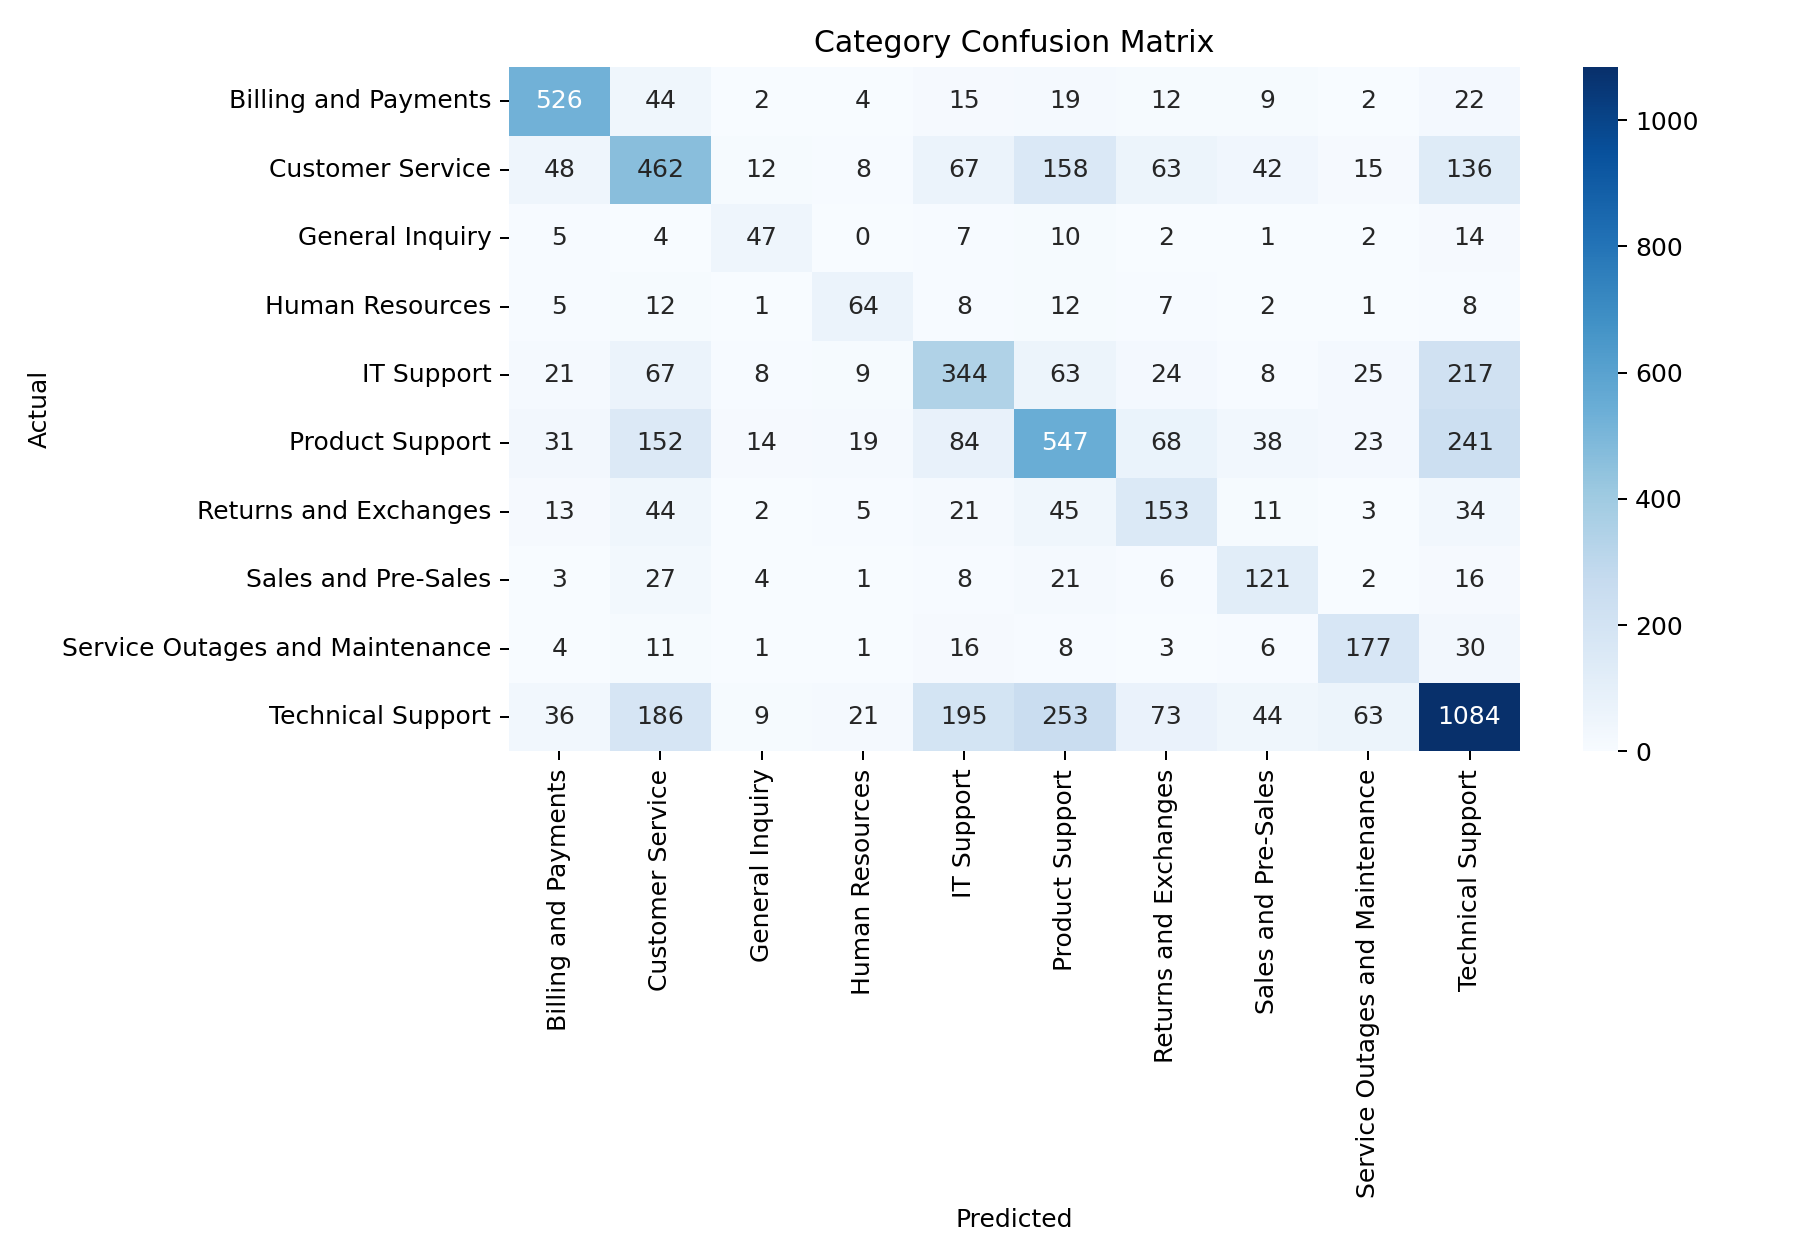

Priority confusion matrix


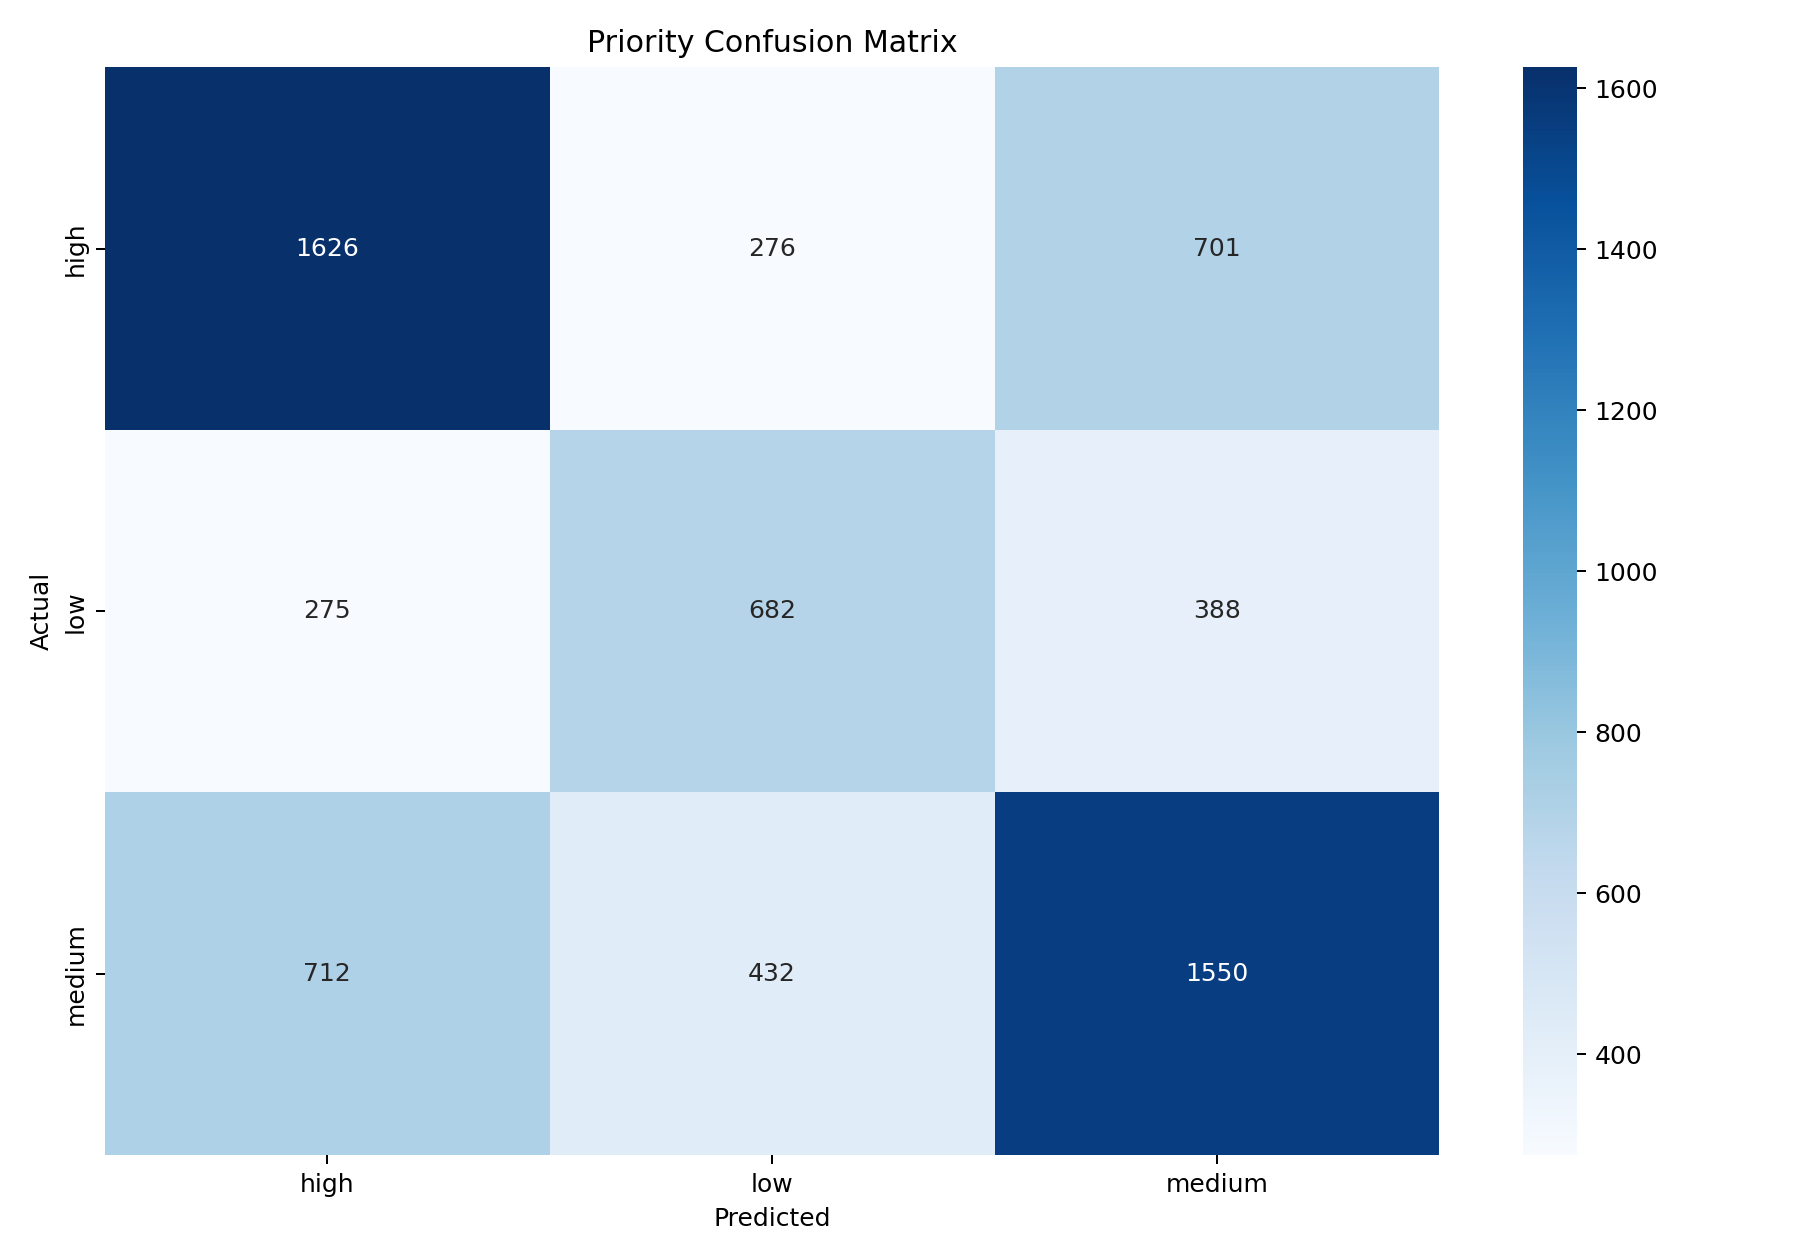

In [5]:
# Display saved confusion matrix figures.
category_cm_path = RESULTS_DIR / 'confusion_matrix_category.png'
priority_cm_path = RESULTS_DIR / 'confusion_matrix_priority.png'

print('Category confusion matrix')
display(Image(filename=str(category_cm_path)))
print('Priority confusion matrix')
display(Image(filename=str(priority_cm_path)))

# **5. Recreate Test Predictions**

We recreate the test split and run the saved models so we can inspect real successful and failed examples.

In [6]:
# Load data, rebuild features, and recreate the held-out test split.
raw = load_project_dataset(COMPATIBLE_DATASET_PATHS)
frame, category_col, priority_col = build_modelling_frame(raw)

_, _, category_test = make_train_validation_test_split(frame, category_col)
_, _, priority_test = make_train_validation_test_split(frame, priority_col)

category_model = joblib.load(MODELS_DIR / 'category_model.pkl')
priority_model = joblib.load(MODELS_DIR / 'priority_model.pkl')

category_predictions = category_model.predict(category_test['model_text'])
priority_predictions = priority_model.predict(priority_test['model_text'])

print(f'Category test rows: {len(category_test):,}')
print(f'Priority test rows: {len(priority_test):,}')

Category test rows: 6,642
Priority test rows: 6,642


In [7]:
# Build an inspection table for category predictions.
category_errors = category_test[['ticket_text', category_col, 'model_text']].copy()
category_errors['predicted_category'] = category_predictions
category_errors['correct'] = category_errors[category_col] == category_errors['predicted_category']

category_errors[['ticket_text', category_col, 'predicted_category', 'correct']].head()

,ticket_text,queue,predicted_category,correct
2566,"Billing Assistance Request Recently, numerous ...",Billing and Payments,Billing and Payments,True
41859,Unplanned Crash of Digital Campaign Our digita...,Product Support,Technical Support,False
28822,Misleading Invoices Incorrect invoices have be...,Billing and Payments,Billing and Payments,True
7763,"Dear Customer Support, I am in need of technic...",Technical Support,Technical Support,True
35777,"Query on Project Management Features Hi, seeki...",Technical Support,Sales and Pre-Sales,False


In [8]:
# Build an inspection table for priority predictions.
priority_errors = priority_test[['ticket_text', priority_col, 'model_text']].copy()
priority_errors['predicted_priority'] = priority_predictions
priority_errors['correct'] = priority_errors[priority_col] == priority_errors['predicted_priority']

priority_errors[['ticket_text', priority_col, 'predicted_priority', 'correct']].head()

,ticket_text,priority,predicted_priority,correct
16824,Problem with Smart-Türklingel I am writing to ...,low,low,True
117,Invoice Discrepancy Concern Dear Customer Supp...,low,medium,False
3232,Support for Medical Data Security Customer Sup...,medium,medium,True
9958,"Customer Support, I am submitting a request to...",low,low,True
3261,Anfrage zur Unterstützung des SaaS-Projekts Se...,high,high,True


# **6. Successful and Failed Examples**

These examples can be used in the report to show both model behaviour and limitations.

In [9]:
# Sample successful category predictions.
category_success_examples = (
    category_errors[category_errors['correct']]
    [['ticket_text', category_col, 'predicted_category']]
    .head(5)
)

category_success_examples

,ticket_text,queue,predicted_category
2566,"Billing Assistance Request Recently, numerous ...",Billing and Payments,Billing and Payments
28822,Misleading Invoices Incorrect invoices have be...,Billing and Payments,Billing and Payments
7763,"Dear Customer Support, I am in need of technic...",Technical Support,Technical Support
42784,Reported Issue with Digital Campaign Metrics T...,Product Support,Product Support
52381,Intermittent Connectivity Issues with AWS Dear...,Technical Support,Technical Support


In [10]:
# Sample failed category predictions.
category_failure_examples = (
    category_errors[~category_errors['correct']]
    [['ticket_text', category_col, 'predicted_category']]
    .head(5)
)

category_failure_examples

,ticket_text,queue,predicted_category
41859,Unplanned Crash of Digital Campaign Our digita...,Product Support,Technical Support
35777,"Query on Project Management Features Hi, seeki...",Technical Support,Sales and Pre-Sales
35288,Unbefugter Zugriff auf medizinische Daten Der ...,Returns and Exchanges,Sales and Pre-Sales
45445,Campagne beendet Digitale Campagnen wurden aus...,IT Support,Product Support
26774,Issues with Software Upgrades Problems with so...,Product Support,IT Support


In [11]:
# Sample successful and failed priority predictions.
priority_success_examples = (
    priority_errors[priority_errors['correct']]
    [['ticket_text', priority_col, 'predicted_priority']]
    .head(5)
)
priority_failure_examples = (
    priority_errors[~priority_errors['correct']]
    [['ticket_text', priority_col, 'predicted_priority']]
    .head(5)
)

print('Priority success examples')
display(priority_success_examples)
print('Priority failure examples')
display(priority_failure_examples)

Priority success examples


,ticket_text,priority,predicted_priority
16824,Problem with Smart-Türklingel I am writing to ...,low,low
3232,Support for Medical Data Security Customer Sup...,medium,medium
9958,"Customer Support, I am submitting a request to...",low,low
3261,Anfrage zur Unterstützung des SaaS-Projekts Se...,high,high
12374,Problem with Data Analytics Service Noticed a ...,high,high


Priority failure examples


,ticket_text,priority,predicted_priority
117,Invoice Discrepancy Concern Dear Customer Supp...,low,medium
42493,Unvorhergesehene Zahlungsinformationenfehler a...,high,medium
16072,"System Update, Multiple Software Applications ...",low,medium
34929,Unexpected Crash of SaaS Platform Possibly Due...,medium,high
15768,Optimierung der Datenauswertung für Finanzstra...,medium,high


# **7. Manual Decision-Support Examples**

These examples show the complete system output: prediction, routing, summary, escalation flag, and explanation terms. The rule layer can still catch some high-risk language even when the statistical classifier is weak.

In [12]:
# Run the full prediction workflow on manually written tickets.
manual_examples = [
    'Subject: Payment failed. Body: Our invoice payment was rejected twice and the finance team needs urgent help before the account is suspended.',
    'Subject: Critical outage. Body: The VPN and internal dashboard are unavailable for the Berlin office and several users cannot work.',
    'Subject: Product question. Body: We need compatibility details for the smart home integration before purchasing the enterprise plan.',
]

[predict_ticket(text) for text in manual_examples]

[{'category': 'Billing and Payments',
  'priority': 'medium',
  'recommended_team': 'Billing and Payments',
  'summary': 'medium priority Billing and Payments ticket: Subject: Payment failed.',
  'escalation_required': True,
  'category_explanation_terms': [('payment', 1.3972035732614658),
   ('invoice', 0.5129004505621327),
   ('finance', 0.18021564221009914),
   ('account', 0.1635071888875131),
   ('failed', 0.06327785735537965),
   ('urgent', 0.055423996676171566),
   ('twice', 0.051355882131986726),
   ('was', 0.03330980201357078)],
  'priority_explanation_terms': [('payment', 0.2696233897366869),
   ('urgent help', 0.16368716947238304),
   ('before', 0.09873957717708064),
   ('needs', 0.09472766782588542),
   ('subject', 0.06362523007200455),
   ('failed', 0.06079637890542485),
   ('team', 0.040145698232534735),
   ('is', 0.023764797981850383)]},
 {'category': 'IT Support',
  'priority': 'high',
  'recommended_team': 'IT Support',
  'summary': 'high priority IT Support ticket: Sub

# **8. Save Error Analysis Tables**

Saving examples makes it easier to reuse them in the report and slides.

In [13]:
# Save compact success and failure tables for reporting.
category_success_examples.to_csv(RESULTS_DIR / 'category_success_examples.csv', index=False)
category_failure_examples.to_csv(RESULTS_DIR / 'category_failure_examples.csv', index=False)
priority_success_examples.to_csv(RESULTS_DIR / 'priority_success_examples.csv', index=False)
priority_failure_examples.to_csv(RESULTS_DIR / 'priority_failure_examples.csv', index=False)

print('Saved success and failure examples to results/.')

Saved success and failure examples to results/.


# **9. Critical Reflection Notes**

These points should guide the report discussion.

In [14]:

# Summarise limitations and next-step recommendations.
reflection_points = [
    'The final models perform clearly better than dummy baselines, especially for queue routing and priority prediction.',
    'Linear SVM was selected for both final tasks because it achieved the strongest validation macro F1-score.',
    'The dataset is multilingual, so performance may vary between English and German tickets and should be monitored.',
    'The answer field is excluded from prediction to avoid target leakage, but it can support response-quality discussion.',
    'The system should remain decision support: urgent, security, outage, and uncertain cases need human review.',
    'Future work could compare sentence-transformer or transformer models against the current TF-IDF baseline.',
]

for point in reflection_points:
    print('-', point)


- The final models perform clearly better than dummy baselines, especially for queue routing and priority prediction.
- Linear SVM was selected for both final tasks because it achieved the strongest validation macro F1-score.
- The dataset is multilingual, so performance may vary between English and German tickets and should be monitored.
- The answer field is excluded from prediction to avoid target leakage, but it can support response-quality discussion.
- The system should remain decision support: urgent, security, outage, and uncertain cases need human review.
- Future work could compare sentence-transformer or transformer models against the current TF-IDF baseline.
